# **2.1.4 - Bài tập thực hành 2: Xây dựng cây quyết định và rừng cây trên dữ liệu bệnh tiểu đường.**

## **1. Tải và khám phá dữ liệu**

In [1]:
import pandas as pd

# Đọc dữ liệu
data = pd.read_csv('dataset/diabetes_prediction_dataset.csv')  # thay bằng đường dẫn thực tế nếu cần
print(data.head())
print(data.info())
print(data.describe())


   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age               

## **2. Tiền xử lý dữ liệu**

In [3]:
# Kiểm tra giá trị thiếu
print(data.isnull().sum())

# Kiểm tra giá trị bất thường (ví dụ: bmi = 0)
print((data['bmi'] == 0).sum())
print((data['blood_glucose_level'] == 0).sum())

# Thay thế giá trị 0 bất hợp lý bằng median
cols_with_zero = ['bmi', 'blood_glucose_level']
for col in cols_with_zero:
    data[col] = data[col].replace(0, data[col].median())

# Mã hóa biến phân loại
data = pd.get_dummies(data, columns=['gender', 'smoking_history'], drop_first=True)


gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64
0
0


## **3. Chia tập huấn luyện và kiểm tra**

In [4]:
from sklearn.model_selection import train_test_split

# Tách đặc trưng và nhãn
X = data.drop('diabetes', axis=1)
y = data['diabetes']

# Chia tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **4. Huấn luyện mô hình Cây quyết định và Rừng cây**

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Cây quyết định
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Rừng cây
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## **5. Đánh giá mô hình**

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Cây quyết định
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

# Rừng cây
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Decision Tree Accuracy: 0.952
[[17777   515]
 [  445  1263]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97     18292
           1       0.71      0.74      0.72      1708

    accuracy                           0.95     20000
   macro avg       0.84      0.86      0.85     20000
weighted avg       0.95      0.95      0.95     20000

Random Forest Accuracy: 0.9699
[[18225    67]
 [  535  1173]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.95      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



**Nhận xét:** Rừng cây cho kết quả vượt trội hơn cây quyết định: độ chính xác tăng từ 95% lên gần 97%, f1-score của lớp tiểu đường cũng cải thiện rõ rệt. Điều này cho thấy Random Forest xử lý tốt hơn sự mất cân bằng giữa hai lớp và giảm sai sót hiệu quả.

## **6. Trực quan hóa cây quyết định**

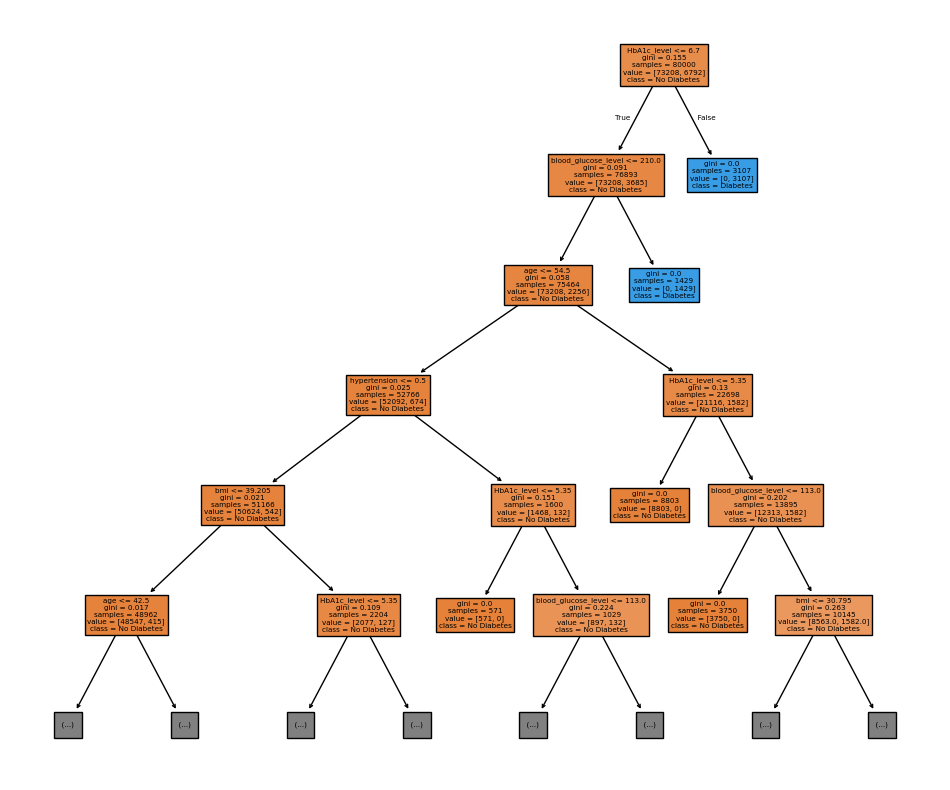

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Diabetes', 'Diabetes'], filled=True, max_depth=5)
plt.show()


**Nhận xét:** Hình này cho thấy mô hình đang phân loại bệnh tiểu đường dựa trên các ngưỡng cụ thể của các đặc trưng như chỉ số đường huyết, HbA1c, BMI, tuổi, và tiền sử bệnh. Điều này phản ánh rõ mối liên hệ giữa các yếu tố sức khỏe và khả năng mắc tiểu đường trong dataset bạn đang dùng. Các đặc trưng này đóng vai trò quyết định trong việc phân tách dữ liệu và dự đoán kết quả. 